# Cluster Analysis – Heart Disease Dataset
*Cluster analysis for Cardio - Risk Prediction project*  

---

## Table of Contents


<a id='imports'></a>
## Reproducibility & Imports  
---

In [ ]:
# Reproducibility
import os, sys
import joblib, pandas as pd

# Imports
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

# Tools
from plotly.io import show
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from scripts.dim_red.plots import plot_3d
from matplotlib import pyplot as plt
from scripts.clustering.utils import rank_leaderboard, build_global_leaderboard, append_result, show_scores, select_k_kmeans, select_k_agglomerative, gridsearch_dbscan, k_distance_plot, gridsearch_kmeans_params, gridsearch_agglomerative_params

SEED = 42
TARGET_COL = "DEATH_EVENT"
OUTPUT_DIR = "../outputs/clustering"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
df_pca = joblib.load('../outputs/dim_red/df_pca.pkl')
df_tsne = joblib.load('../outputs/dim_red/df_tsne.pkl')
df_umap = joblib.load('../outputs/dim_red/df_umap.pkl')
df_mix = joblib.load('../outputs/dim_red/df_mix.pkl')
df_preprocessed = joblib.load('../outputs/eda/df_preprocessed_balanced.pkl')

In [3]:
X_pca  = df_pca.iloc[:, :-1]
X_tsne = df_tsne.iloc[:, :-1]
X_umap = df_umap.iloc[:, :-1]
X_mix = df_mix.iloc[:, :-1]
X_pre  = df_preprocessed.iloc[:, :-1]
y = df_preprocessed.iloc[:, -1]

cols_to_drop = ['high_blood_pressure', 'platelets', 'sex', 'creatinine_phosphokinase', 'anaemia', 'smoking', 'diabetes']
X_pre = X_pre.drop(columns=cols_to_drop)

datasets = {
    "pca": X_pca,
    "tsne": X_tsne,
    "umap": X_umap,
    "mix": X_mix,
}

rows: list[dict] = []

## DBSCAN

In [4]:
dbscan_params = {
    "pca":  {"eps": 0.2, "min_samples": 5},
    "tsne": {"eps": 1.2, "min_samples": 3},
    "umap": {"eps": 0.8, "min_samples": 10},
    "mix":  {"eps": 0.8, "min_samples": 3},
}

for name, X in datasets.items():
    p = dbscan_params[name]
    
    db = DBSCAN(eps=p["eps"], min_samples=p["min_samples"])
    labels = db.fit_predict(X)

    scores = show_scores(f"DBSCAN on {name}", X, labels, y)
    append_result(rows, name, "dbscan", labels, scores["internal"], scores["external"], params=p)

    fig = plot_3d(X3d=X, y=labels, algorithm=f'DBSCAN on {name}', target_name="cluster")
    show(fig)


[DBSCAN on pca] -> clusters=2, noise=4.2%, sil=0.21317452249465685, CH=8.68334275600144, DB=3.447573905424029, ARI=0.05214570347001016, NMI=0.048469451828312284, V=0.04846945182831228


[DBSCAN on tsne] -> clusters=25, noise=7.5%, sil=0.12047891318798065, CH=46.4655876159668, DB=1.6171936861523126, ARI=0.043519243485287455, NMI=0.18252636941385084, V=0.18252636941385084


[DBSCAN on umap] -> clusters=5, noise=0.6%, sil=0.4236181676387787, CH=219.84384155273438, DB=0.9559692510718913, ARI=0.15524995993479257, NMI=0.17600014966472874, V=0.17600014966472874


[DBSCAN on mix] -> clusters=3, noise=0.0%, sil=0.3987852531047934, CH=429.52204632858405, DB=0.587011766242988, ARI=0.04493476072176693, NMI=0.15622307611350766, V=0.15622307611350766


## KMeans

In [5]:
kmeans_params = {
    "pca":  {"k": 4, "n_init": 20},
    "tsne": {"k": 5, "n_init": 10},
    "umap": {"k": 5, "n_init": 10},
    "mix":  {"k": 2, "n_init": 10},
}

for name, X in datasets.items():
    p = kmeans_params[name]
    
    km = KMeans(n_clusters=p["k"], n_init=p["n_init"], random_state=SEED)
    labels = km.fit_predict(X)

    scores = show_scores(f"KMeans on {name}", X, labels, y)
    append_result(rows, name, "kmeans", labels, scores["internal"], scores["external"], params=p)

    fig = plot_3d(X3d=X, y=labels, algorithm=f'KMeans on {name}', target_name="cluster")
    show(fig)

[KMeans on pca] -> clusters=4, noise=0.0%, sil=0.3176439730002902, CH=150.30032628161473, DB=1.0678346669027357, ARI=0.12714911317434913, NMI=0.15084770183414495, V=0.15084770183414498


[KMeans on tsne] -> clusters=5, noise=0.0%, sil=0.39721426367759705, CH=227.57489013671875, DB=0.8871370582053826, ARI=0.16105180324185542, NMI=0.21694863690232513, V=0.21694863690232516


[KMeans on umap] -> clusters=5, noise=0.0%, sil=0.5001122355461121, CH=325.3822937011719, DB=0.7193349161030735, ARI=0.18879531524692741, NMI=0.18877574870669203, V=0.18877574870669203


[KMeans on mix] -> clusters=2, noise=0.0%, sil=0.5786823175821805, CH=720.055654798926, DB=0.5732303091627815, ARI=0.15706961320453955, NMI=0.2105112732965428, V=0.21051127329654276


## Aglomerative

In [6]:
agglo_params = {
    "pca":  {"k": 7, "linkage": "ward",     "metric": "euclidean"},
    "tsne": {"k": 5, "linkage": "complete", "metric": "euclidean"},
    "umap": {"k": 7, "linkage": "average",  "metric": "manhattan"},
    "mix":  {"k": 2, "linkage": "ward",     "metric": "euclidean"},
}

for name, X in datasets.items():
    p = agglo_params[name]
    
    agg = AgglomerativeClustering(n_clusters=p["k"], linkage=p["linkage"], metric=p["metric"])
    labels = agg.fit_predict(X)

    scores = show_scores(f"Agglomerative on {name}", X, labels, y)
    append_result(rows, name, "agglomerative", labels, scores["internal"], scores["external"], params=p)

    fig = plot_3d(X3d=X, y=labels, algorithm=f'Agglomerative on {name}', target_name="cluster")
    show(fig)

[Agglomerative on pca] -> clusters=7, noise=0.0%, sil=0.2809326919123936, CH=115.42192839568682, DB=1.0806819337161506, ARI=0.18201909845392264, NMI=0.2641136284896929, V=0.2641136284896929


[Agglomerative on tsne] -> clusters=5, noise=0.0%, sil=0.3733208477497101, CH=204.91714477539062, DB=0.8815848806632423, ARI=0.15656092734531793, NMI=0.20367834014990624, V=0.20367834014990624


[Agglomerative on umap] -> clusters=7, noise=0.0%, sil=0.4718312919139862, CH=335.157958984375, DB=0.6372203903983433, ARI=0.18697689302237325, NMI=0.2450580986664114, V=0.24505809866641134


[Agglomerative on mix] -> clusters=2, noise=0.0%, sil=0.5949226817019988, CH=631.5637530451563, DB=0.46358778231756764, ARI=0.018841639529996304, NMI=0.1655762113155323, V=0.1655762113155323


## Best params finder

[pca] DBSCAN best: {'eps': 0.2, 'min_samples': 5} {'silhouette': 0.21317452249465685, 'calinski_harabasz': 8.68334275600144, 'davies_bouldin': 3.447573905424029, 'n_clusters': 2, 'noise_%': 4.220779220779221}
[tsne] DBSCAN best: {'eps': 1.2, 'min_samples': 3} {'silhouette': 0.12047891318798065, 'calinski_harabasz': 46.4655876159668, 'davies_bouldin': 1.6171936861523126, 'n_clusters': 25, 'noise_%': 7.467532467532467}
[umap] DBSCAN best: {'eps': 0.8, 'min_samples': 10} {'silhouette': 0.4236181676387787, 'calinski_harabasz': 219.84384155273438, 'davies_bouldin': 0.9559692510718913, 'n_clusters': 5, 'noise_%': 0.6493506493506493}
[mix] DBSCAN best: {'eps': 0.8, 'min_samples': 3} {'silhouette': 0.3987852531047934, 'calinski_harabasz': 429.52204632858405, 'davies_bouldin': 0.587011766242988, 'n_clusters': 3, 'noise_%': 0.0}


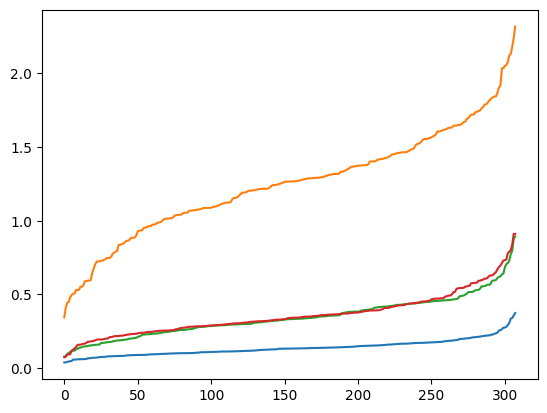

In [7]:
dbscan_best = {}
for name, X in datasets.items():
    kd = k_distance_plot(X=X)
    plt.plot(kd)
    
    db_best = gridsearch_dbscan(X=X)
    dbscan_best[name] = db_best
    print(f"[{name}] DBSCAN best:", db_best["params"], db_best["metrics"])


In [8]:
kmeans_best = {}
agglom_best = {}

for name, X in datasets.items():
    kmeans_best[name]  = gridsearch_kmeans_params(X, ks=range(2, 8), n_inits=(10, 20))
    agglom_best[name]  = gridsearch_agglomerative_params(
        X,
        ks=range(2, 8),
        linkages=("ward","complete","average"),
        metrics=("euclidean","manhattan","cosine")
    )
    print(f"[{name}] KMeans best:", kmeans_best[name]["params"])
    print(f"[{name}] Agglomerative best:", agglom_best[name]["params"])

[pca] KMeans best: {'k': 4, 'n_init': 20}
[pca] Agglomerative best: {'k': 7, 'linkage': 'ward', 'metric': 'euclidean'}
[tsne] KMeans best: {'k': 5, 'n_init': 10}
[tsne] Agglomerative best: {'k': 5, 'linkage': 'complete', 'metric': 'euclidean'}
[umap] KMeans best: {'k': 5, 'n_init': 10}
[umap] Agglomerative best: {'k': 7, 'linkage': 'average', 'metric': 'manhattan'}
[mix] KMeans best: {'k': 2, 'n_init': 10}
[mix] Agglomerative best: {'k': 2, 'linkage': 'ward', 'metric': 'euclidean'}


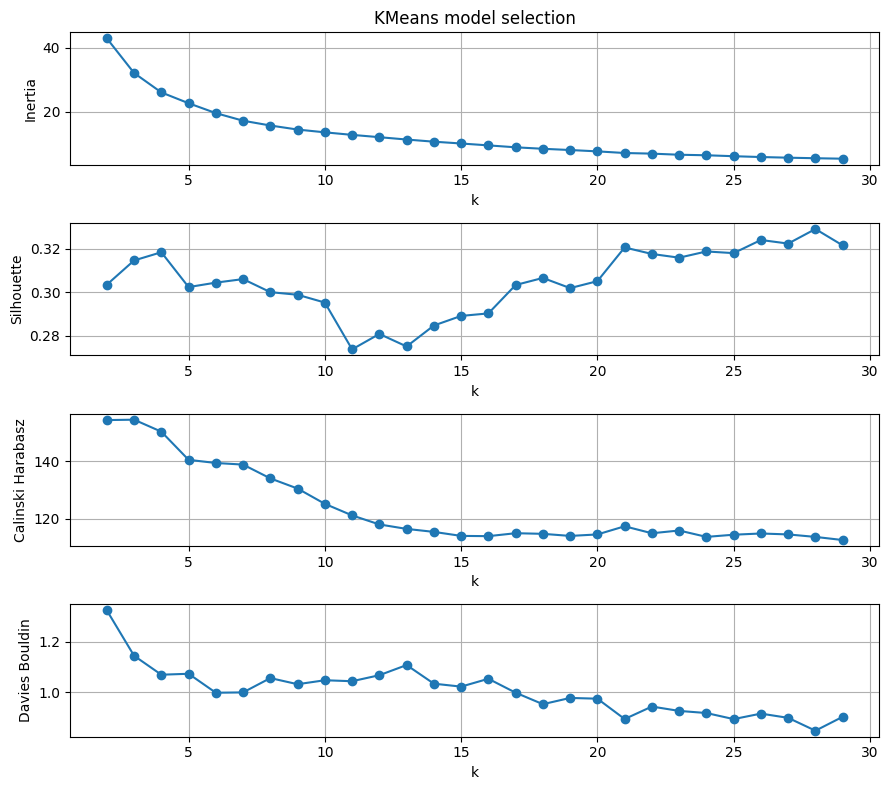

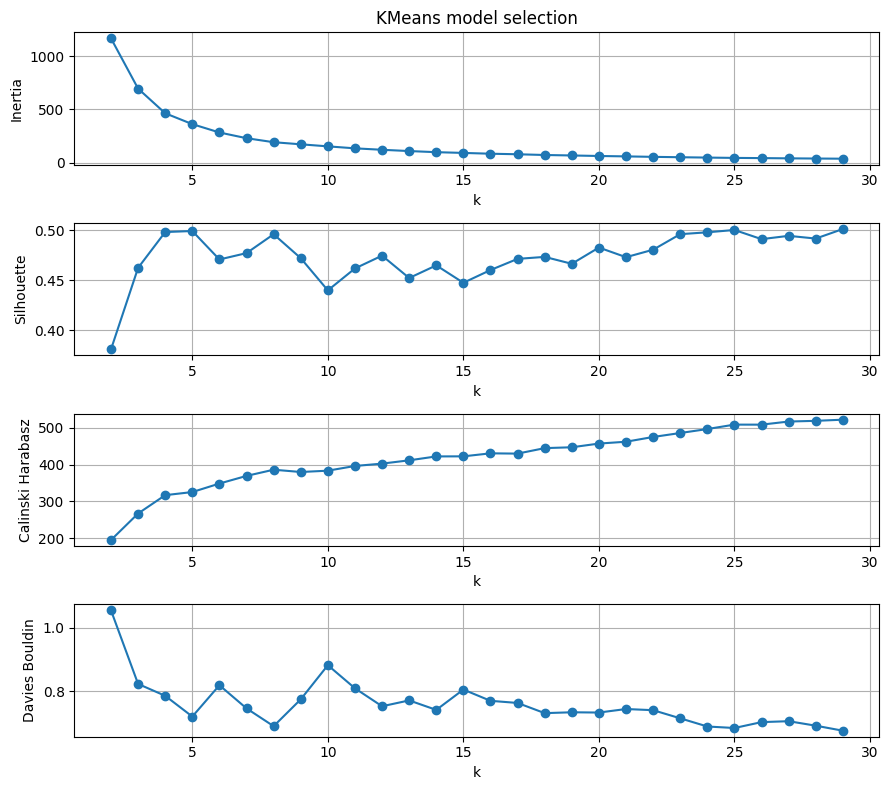

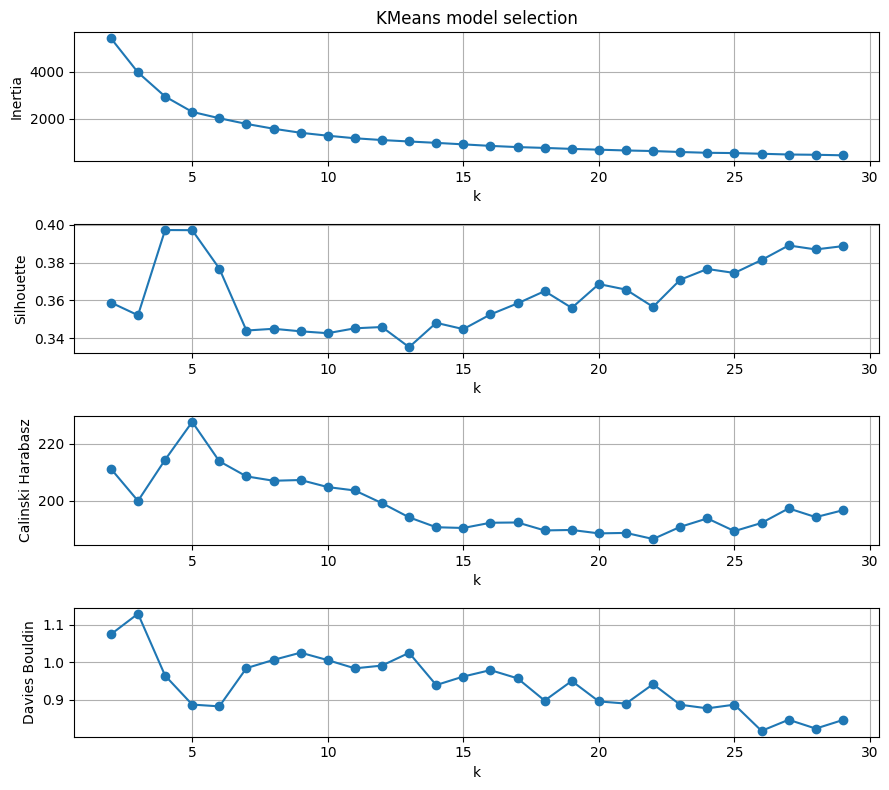

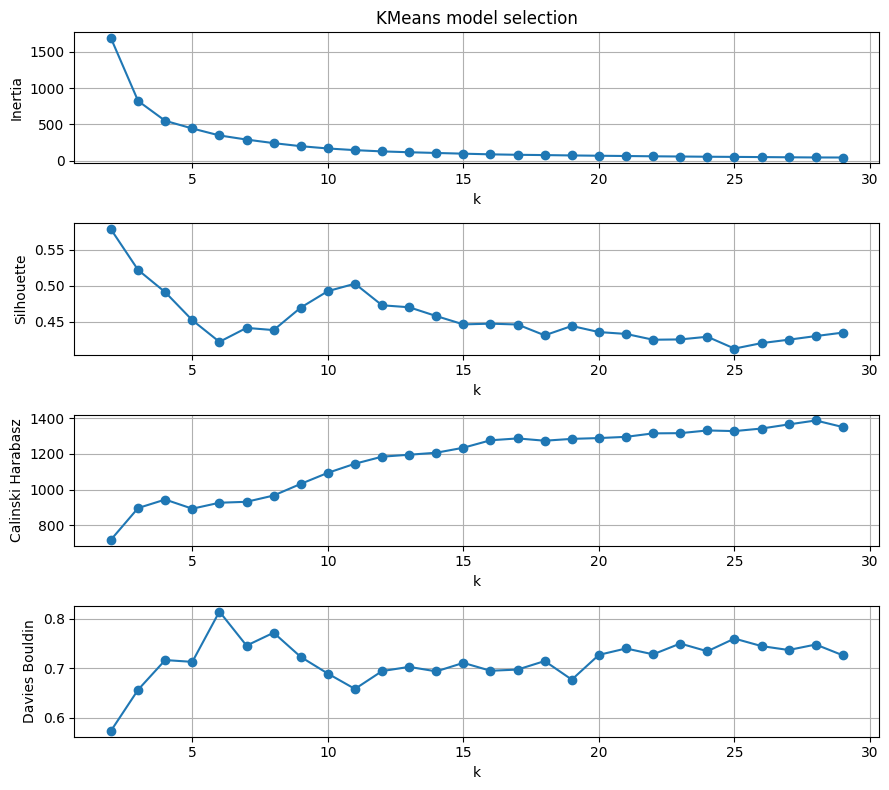


KMeans on PCA
{'inertia': 29, 'silhouette': 28, 'calinski_harabasz': 3, 'davies_bouldin': 28}

KMeans on UMAP
{'inertia': 29, 'silhouette': 29, 'calinski_harabasz': 29, 'davies_bouldin': 29}

KMeans on T-SNE
{'inertia': 29, 'silhouette': 4, 'calinski_harabasz': 5, 'davies_bouldin': 26}

KMeans on MIX
{'inertia': 29, 'silhouette': 2, 'calinski_harabasz': 28, 'davies_bouldin': 2}


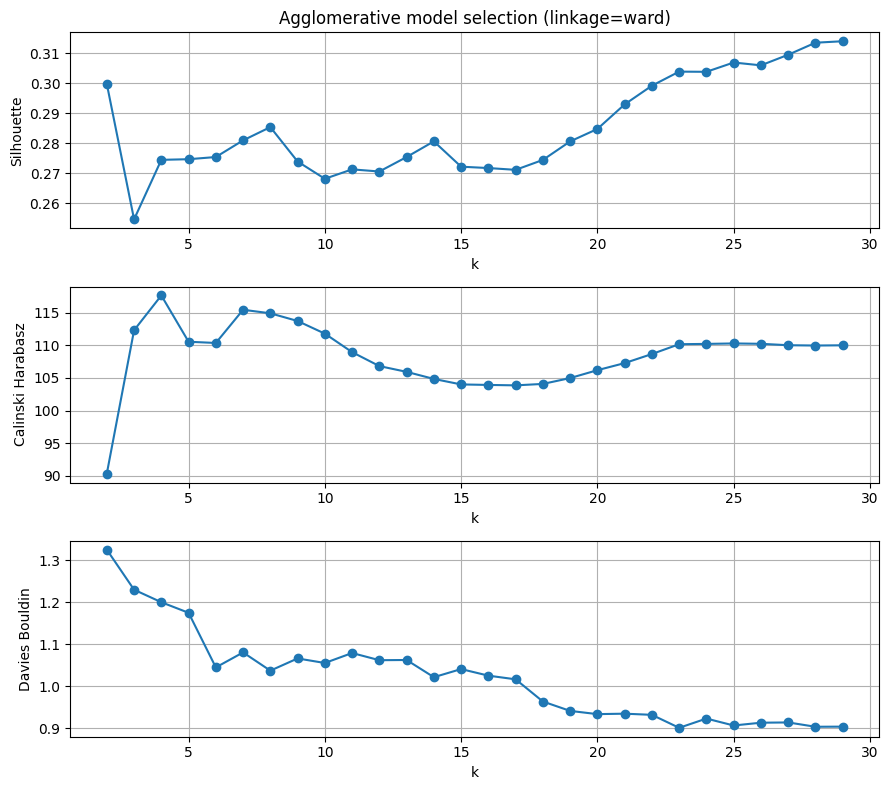

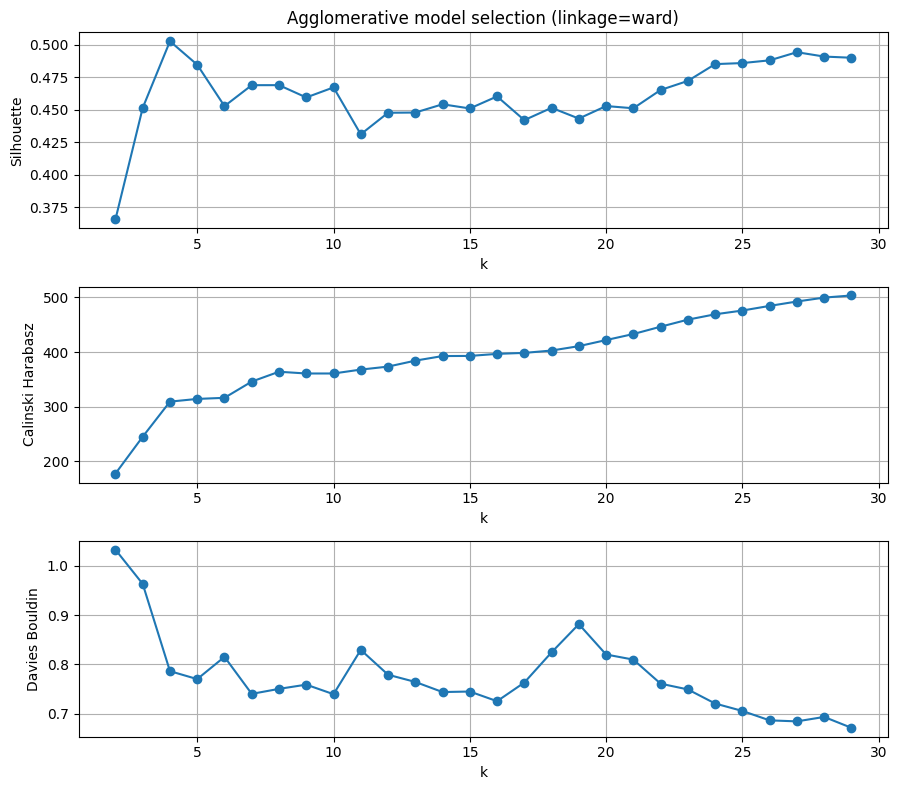

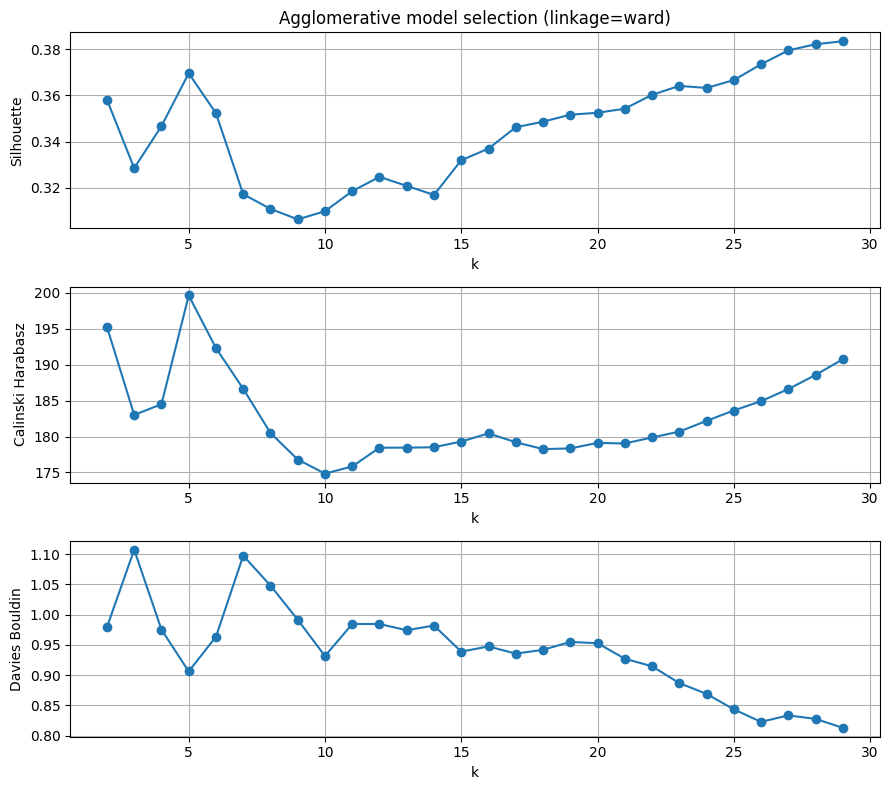

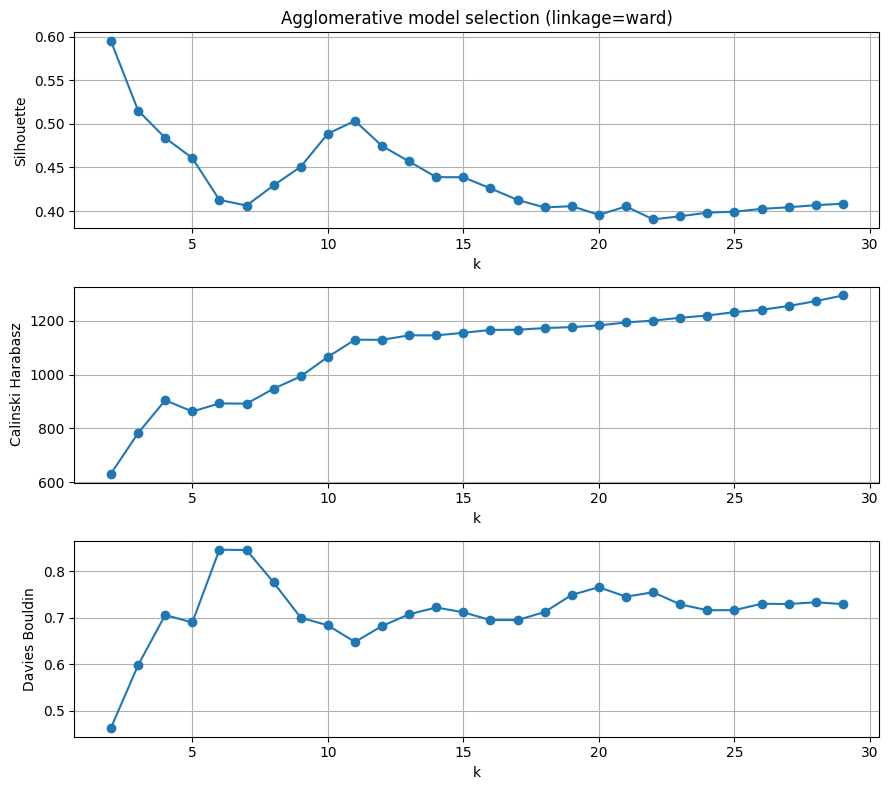


Agglomerative on PCA
{'silhouette': 29, 'calinski_harabasz': 4, 'davies_bouldin': 23}

Agglomerative on UMAP
{'silhouette': 4, 'calinski_harabasz': 29, 'davies_bouldin': 29}

Agglomerative on T-SNE
{'silhouette': 29, 'calinski_harabasz': 5, 'davies_bouldin': 29}

Agglomerative on MIX
{'silhouette': 2, 'calinski_harabasz': 29, 'davies_bouldin': 2}


In [9]:
# KMEANS
kmeans_results = {}
kmeans_results['pca'] = select_k_kmeans(X_pca,  k_range=range(2, 30), n_init=50)
kmeans_results['umap'] = select_k_kmeans(X_umap, k_range=range(2, 30), n_init=50)
kmeans_results['t-SNE'] = select_k_kmeans(X_tsne, k_range=range(2, 30), n_init=50)
kmeans_results['MIX'] = select_k_kmeans(X_mix, k_range=range(2, 30), n_init=50)

for name, res in kmeans_results.items():
    print(f"\nKMeans on {name.upper()}")
    print(res.best_by_metric)
    
# AGGLOMERATIVE
agg_results = {}
agg_results['pca'] = select_k_agglomerative(X_pca,  k_range=range(2, 30))
agg_results['umap'] = select_k_agglomerative(X_umap, k_range=range(2, 30))
agg_results['t-SNE'] = select_k_agglomerative(X_tsne, k_range=range(2, 30))
agg_results['MIX'] = select_k_agglomerative(X_mix, k_range=range(2, 30))

for name, res in agg_results.items():
    print(f"\nAgglomerative on {name.upper()}")
    print(res.best_by_metric)

### Best result overall

In [10]:
board = build_global_leaderboard(datasets)
ordered = rank_leaderboard(board)

rows = []
for i, r in enumerate(ordered, 1):
    m = r["metrics"]
    rows.append({
        "Rank": i,
        "Embedding": r["emb"].upper(),
        "Algorithm": r["algo"].upper(),
        "Params": str(r["params"]),
        "Clusters": m.get("n_clusters"),
        "Silhouette": round(m.get("silhouette"), 4),
        "Calinski-Harabasz": round(m.get("calinski_harabasz"), 2),
        "Davies-Bouldin": round(m.get("davies_bouldin"), 4)
    })

df_leaderboard = pd.DataFrame(rows)

display(df_leaderboard.style
    .background_gradient(subset=["Silhouette"], cmap="Greens")
    .background_gradient(subset=["Davies-Bouldin"], cmap="Reds_r")
    .format({"Silhouette": "{:.4f}", "Calinski-Harabasz": "{:.2f}", "Davies-Bouldin": "{:.4f}"})
)


,Rank,Embedding,Algorithm,Params,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,1,MIX,AGGLOMERATIVE,"{'k': 11, 'linkage': 'ward', 'metric': 'euclidean'}",11,0.5035,1129.93,0.6482
1,2,MIX,KMEANS,"{'k': 11, 'n_init': 10}",11,0.5015,1144.55,0.6594
2,3,UMAP,KMEANS,"{'k': 8, 'n_init': 10}",8,0.4971,385.76,0.6858
3,4,UMAP,AGGLOMERATIVE,"{'k': 8, 'linkage': 'complete', 'metric': 'euclidean'}",8,0.4854,365.70,0.7085
4,5,UMAP,DBSCAN,"{'eps': 0.8, 'min_samples': 10}",5,0.4236,219.84,0.9560
5,6,MIX,DBSCAN,"{'eps': 0.8, 'min_samples': 3}",3,0.3988,429.52,0.5870
6,7,TSNE,KMEANS,"{'k': 5, 'n_init': 10}",5,0.3972,227.57,0.8871
7,8,TSNE,AGGLOMERATIVE,"{'k': 5, 'linkage': 'complete', 'metric': 'euclidean'}",5,0.3733,204.92,0.8816
8,9,PCA,KMEANS,"{'k': 6, 'n_init': 20}",6,0.3042,139.44,0.9985
9,10,PCA,AGGLOMERATIVE,"{'k': 8, 'linkage': 'ward', 'metric': 'euclidean'}",8,0.2854,114.88,1.0374


### Cluster profile of TOP-5

In [11]:
topK = 5
interpretation = {}

for i, r in enumerate(ordered[:topK], 1):
    labels = r["labels"]
    algo   = r["algo"].upper()
    emb    = r["emb"].upper()
    params = r["params"]
    m      = r["metrics"]

    # compute profile on original features
    X_orig = X_pre.copy()
    prof, overall = cluster_profile(X_orig, labels)
    interpretation[(emb, algo, i)] = {"profile": prof, "overall": overall, "params": params, "metrics": m}

    # header + quick metrics
    print(f"\n=== {i}. {emb} – {algo} ===  \nparams={params}")
    display(prof)


=== 1. MIX – AGGLOMERATIVE ===  
params={'k': 11, 'linkage': 'ward', 'metric': 'euclidean'}


age                     ejection_fraction                      \
              mean    median       std              mean    median       std   
_cluster                                                                       
0         0.325895  0.281818  0.194067          0.473237  0.448598  0.124885   
1         0.303109  0.272727  0.199191          0.370210  0.392523  0.117859   
2         0.243760  0.272727  0.135739          0.410298  0.448598  0.167346   
3         0.364522  0.363636  0.133381          0.451009  0.448598  0.257339   
4         0.528293  0.517547  0.125914          0.210419  0.205607  0.067770   
5         0.323907  0.363636  0.175344          0.398338  0.392523  0.109674   
6         0.672686  0.661411  0.085610          0.439037  0.448598  0.207022   
7         0.391411  0.445455  0.221248          0.509815  0.532710  0.273248   
8         0.305173  0.327273  0.148000          0.684508  0.859813  0.321567   
9         0.244095  0.245909  0.054637          0.235983  0.231579  0.121475   
10        0.831610  0.838867  0.107572          0.520516  0.478817  0.112150   

         serum_creatinine                     serum_sodium            \
                     mean    median       std         mean    median   
_cluster                                                               
0                0.468864  0.453505  0.201897     0.456522  0.478261   
1                0.361998  0.387744  0.118592     0.605605  0.630435   
2                0.386844  0.387744  0.129796     0.474621  0.521739   
3                0.817702  0.938041  0.236154     0.446449  0.454811   
4                0.421924  0.409932  0.060366     0.638546  0.642351   
5                0.291769  0.318610  0.091756     0.497585  0.478261   
6                0.764704  0.855613  0.207490     0.403741  0.391304   
7                0.652265  0.687423  0.273445     0.467238  0.478261   
8                0.546391  0.503897  0.275823     0.455771  0.521739   
9                0.523662  0.489910  0.122035     0.552423  0.565217   
10               0.490366  0.421768  0.179058     0.602202  0.605397   

                        time                      
               std      mean    median       std  
_cluster                                          
0         0.120993  0.767227  0.741993  0.103647  
1         0.122339  0.781064  0.779359  0.101491  
2         0.214468  0.255902  0.281139  0.102538  
3         0.232865  0.221266  0.241993  0.126754  
4         0.102929  0.113798  0.048143  0.108856  
5         0.108751  0.412033  0.412811  0.075682  
6         0.093945  0.210891  0.252669  0.148647  
7         0.247218  0.686348  0.676157  0.091900  
8         0.252962  0.387365  0.362989  0.138428  
9         0.072002  0.122399  0.135140  0.071517  
10        0.148312  0.087293  0.067555  0.062798


=== 2. MIX – KMEANS ===  
params={'k': 11, 'n_init': 10}


age                     ejection_fraction                      \
              mean    median       std              mean    median       std   
_cluster                                                                       
0         0.236752  0.272727  0.131040          0.408489  0.448598  0.167221   
1         0.324908  0.272727  0.191610          0.479143  0.448598  0.125718   
2         0.649903  0.641939  0.098955          0.420690  0.448598  0.216174   
3         0.301134  0.272727  0.202352          0.367251  0.392523  0.116349   
4         0.528293  0.517547  0.125914          0.210419  0.205607  0.067770   
5         0.323907  0.363636  0.175344          0.398338  0.392523  0.109674   
6         0.360074  0.363636  0.135570          0.466262  0.448598  0.255071   
7         0.254165  0.247971  0.068894          0.247173  0.257550  0.127733   
8         0.308280  0.327273  0.149750          0.694936  0.859813  0.322436   
9         0.830199  0.823189  0.103118          0.509372  0.471653  0.114647   
10        0.392127  0.445455  0.215730          0.506271  0.467290  0.261431   

         serum_creatinine                     serum_sodium            \
                     mean    median       std         mean    median   
_cluster                                                               
0                0.392649  0.387744  0.136718     0.475625  0.521739   
1                0.445740  0.453505  0.180318     0.457052  0.478261   
2                0.763412  0.842203  0.203130     0.400300  0.391304   
3                0.365519  0.387744  0.120172     0.602643  0.608696   
4                0.421924  0.409932  0.060366     0.638546  0.642351   
5                0.291769  0.318610  0.091756     0.497585  0.478261   
6                0.819017  0.973062  0.242269     0.451512  0.458416   
7                0.519969  0.463614  0.119684     0.546882  0.565217   
8                0.543281  0.503897  0.280366     0.454967  0.521739   
9                0.518462  0.436737  0.199128     0.585979  0.585433   
10               0.674628  0.757987  0.273054     0.464534  0.478261   

                        time                      
               std      mean    median       std  
_cluster                                          
0         0.214407  0.264757  0.291815  0.103889  
1         0.124928  0.771895  0.743772  0.109218  
2         0.094747  0.206053  0.229440  0.148141  
3         0.122424  0.774321  0.750890  0.097569  
4         0.102929  0.113798  0.048143  0.108856  
5         0.108751  0.412033  0.412811  0.075682  
6         0.237710  0.228902  0.249110  0.125309  
7         0.074025  0.123238  0.135231  0.069598  
8         0.257566  0.386456  0.359431  0.140880  
9         0.153574  0.086340  0.071174  0.060222  
10        0.236750  0.696619  0.686833  0.096432


=== 3. UMAP – KMEANS ===  
params={'k': 8, 'n_init': 10}


age                     ejection_fraction                      \
              mean    median       std              mean    median       std   
_cluster                                                                       
0         0.273200  0.272727  0.159592          0.407217  0.400551  0.138370   
1         0.327733  0.327273  0.172585          0.365305  0.392523  0.119891   
2         0.434507  0.407627  0.213512          0.370300  0.362259  0.237000   
3         0.743348  0.746105  0.115600          0.534075  0.488148  0.110183   
4         0.529533  0.545455  0.121501          0.456266  0.448598  0.181512   
5         0.396737  0.363636  0.176034          0.212701  0.205607  0.089554   
6         0.169565  0.181818  0.105326          0.475767  0.448598  0.186138   
7         0.377800  0.418182  0.131378          0.861316  0.859813  0.052496   

         serum_creatinine                     serum_sodium            \
                     mean    median       std         mean    median   
_cluster                                                               
0                0.341796  0.318610  0.122738     0.492100  0.521739   
1                0.792653  0.792232  0.158542     0.421055  0.456522   
2                0.903569  0.933067  0.110877     0.374228  0.391304   
3                0.468071  0.489545  0.089751     0.554447  0.521739   
4                0.429116  0.453505  0.115641     0.538968  0.521739   
5                0.472442  0.453505  0.110315     0.599277  0.598812   
6                0.327349  0.387744  0.111665     0.536446  0.565217   
7                0.413390  0.387744  0.173735     0.578908  0.543478   

                        time                      
               std      mean    median       std  
_cluster                                          
0         0.169400  0.320659  0.316726  0.120296  
1         0.182405  0.779211  0.758007  0.130377  
2         0.215222  0.226500  0.231931  0.152737  
3         0.133745  0.204637  0.179715  0.149777  
4         0.188127  0.747323  0.729537  0.096677  
5         0.099435  0.115344  0.109416  0.092982  
6         0.146950  0.750674  0.747331  0.098729  
7         0.138364  0.322627  0.322064  0.144921


=== 4. UMAP – AGGLOMERATIVE ===  
params={'k': 8, 'linkage': 'complete', 'metric': 'euclidean'}


age                     ejection_fraction                      \
              mean    median       std              mean    median       std   
_cluster                                                                       
0         0.434507  0.407627  0.213512          0.370300  0.362259  0.237000   
1         0.281258  0.272727  0.164010          0.433858  0.448598  0.119601   
2         0.547156  0.545455  0.119581          0.476636  0.448598  0.200537   
3         0.359089  0.301014  0.180415          0.225830  0.205607  0.117270   
4         0.729596  0.745455  0.129101          0.540685  0.490314  0.111584   
5         0.198455  0.181818  0.128284          0.463940  0.448598  0.178902   
6         0.371650  0.409091  0.135723          0.869948  0.859813  0.035349   
7         0.327733  0.327273  0.172585          0.365305  0.392523  0.119891   

         serum_creatinine                     serum_sodium            \
                     mean    median       std         mean    median   
_cluster                                                               
0                0.903569  0.933067  0.110877     0.374228  0.391304   
1                0.338312  0.318610  0.125524     0.527590  0.543478   
2                0.460875  0.453505  0.108774     0.544060  0.521739   
3                0.451039  0.451500  0.115272     0.537436  0.565217   
4                0.473216  0.503897  0.090600     0.552889  0.521739   
5                0.322050  0.318610  0.109717     0.529036  0.521739   
6                0.393488  0.387744  0.166669     0.588057  0.565217   
7                0.792653  0.792232  0.158542     0.421055  0.456522   

                        time                      
               std      mean    median       std  
_cluster                                          
0         0.215222  0.226500  0.231931  0.152737  
1         0.137086  0.357437  0.366107  0.091257  
2         0.200333  0.746379  0.729537  0.091494  
3         0.177833  0.116481  0.104530  0.088765  
4         0.130554  0.206416  0.241993  0.146212  
5         0.140331  0.752858  0.747331  0.097968  
6         0.140482  0.313458  0.322064  0.137143  
7         0.182405  0.779211  0.758007  0.130377


=== 5. UMAP – DBSCAN ===  
params={'eps': 0.8, 'min_samples': 10}


age                     ejection_fraction                      \
              mean    median       std              mean    median       std   
_cluster                                                                       
-1        0.327273  0.327273  0.154278          0.626168  0.626168  0.330424   
 0        0.317776  0.292938  0.175257          0.337031  0.378135  0.154348   
 1        0.389997  0.427273  0.132804          0.854011  0.859813  0.062450   
 2        0.438302  0.418182  0.213428          0.369910  0.348879  0.239088   
 3        0.743348  0.746105  0.115600          0.534075  0.488148  0.110183   
 4        0.328380  0.281818  0.204423          0.434476  0.448598  0.167184   

         serum_creatinine                     serum_sodium            \
                     mean    median       std         mean    median   
_cluster                                                               
-1               0.660992  0.660992  0.038906     0.456522  0.456522   
 0               0.388936  0.387744  0.133640     0.530772  0.565217   
 1               0.399720  0.387744  0.158106     0.597922  0.565217   
 2               0.908307  0.938041  0.105772     0.372403  0.391304   
 3               0.468071  0.489545  0.089751     0.554447  0.521739   
 4               0.468466  0.453505  0.220755     0.506742  0.521739   

                        time                      
               std      mean    median       std  
_cluster                                          
-1        0.030744  0.508897  0.508897  0.135885  
 0        0.156246  0.246576  0.266904  0.148595  
 1        0.141448  0.358171  0.339858  0.186898  
 2        0.216682  0.223231  0.211192  0.152034  
 3        0.133745  0.204637  0.179715  0.149777  
 4        0.174109  0.756635  0.741993  0.106072

In [12]:
import numpy as np
import pandas as pd

def compute_smds(X: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    """
    Compute standardized mean differences (SMDs) per feature × cluster.
    |SMD| = |mean_cluster - mean_all| / std_all
    """
    labels = np.asarray(labels)
    if len(labels) != len(X):
        raise ValueError(f"labels length {len(labels)} != X length {len(X)}")

    Xn = X.select_dtypes(include="number").copy()
    df = Xn.copy()
    df["_cluster"] = labels

    mean_all = Xn.mean()
    std_all  = Xn.std(ddof=0).replace(0, np.finfo(float).eps)

    smd_df = pd.DataFrame(index=Xn.columns)
    for c, g in df.groupby("_cluster"):
        mean_c = g.drop(columns="_cluster").mean()
        smd_df[f"Cluster {c}"] = (mean_c - mean_all) / std_all

    return smd_df


# --- Compute SMD tables for the top-5 leaderboard entries ---
topK = 5
X_orig = X_pre.select_dtypes(include="number").copy()
top_smd_tables = {}

for i, r in enumerate(ordered[:topK], 1):
    smd_df = compute_smds(X_orig, r["labels"])
    top_smd_tables[(i, r["emb"].upper(), r["algo"].upper())] = smd_df

print(f"✅ Computed SMD tables for {len(top_smd_tables)} models.")


✅ Computed SMD tables for 5 models.


In [13]:
import pandas as pd
import numpy as np

def top_union_smd_table(smd_df: pd.DataFrame, top_n: int = 8, feature_order: str = "max"):
    """
    Create one wide table:
      - rows: features (each appears once)
      - columns: Cluster 0..K with |SMD| values
      - features = union of top-N |SMD| from each cluster
      - feature order:
          "max"  -> by descending max |SMD| across clusters
          "sum"  -> by descending sum |SMD| across clusters
          "alpha"-> alphabetical by feature name
          None   -> no reordering (original index order)
    """
    # 1) union of top-N features per cluster
    top_sets = []
    for c in smd_df.columns:
        top_feats = smd_df[c].abs().nlargest(top_n).index
        top_sets.append(set(top_feats))
    all_feats = sorted(set().union(*top_sets))  # de-duplicate

    # 2) build matrix Feature x Cluster with |SMD|
    out = pd.DataFrame(index=all_feats)
    for c in smd_df.columns:  # keep original cluster column order
        col = smd_df[c].abs().reindex(all_feats)
        # keep values only for that cluster's top-N, else NaN
        top_mask = smd_df[c].abs().rank(ascending=False, method="first") <= top_n
        allowed = set(smd_df.index[top_mask])
        col = col.where(out.index.to_series().isin(allowed))
        out[c] = col

    # 3) choose feature order
    if feature_order == "max":
        order = out.max(axis=1).sort_values(ascending=False).index
    elif feature_order == "sum":
        order = out.sum(axis=1, skipna=True).sort_values(ascending=False).index
    elif feature_order == "alpha":
        order = sorted(out.index)
    else:
        order = out.index  # as-is

    out = out.loc[order]
    out.index.name = "Feature"
    return out

# --- Example for the #1 leaderboard model ---
rank1_key = (1, ordered[0]['emb'].upper(), ordered[0]['algo'].upper())
smd_df = top_smd_tables[rank1_key]

union_tbl = top_union_smd_table(smd_df, top_n=8, feature_order="max")
display(
    union_tbl.style
        .format("{:.3f}")
        .set_caption(f"Top-8 |SMD| (union) per cluster — {rank1_key[1]} – {rank1_key[2]}")
)


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10
Feature,,,,,,,,,,,
age,0.241,0.348,0.625,0.061,0.705,0.251,1.379,0.065,0.338,0.624,2.122
time,1.220,1.269,0.609,0.733,1.117,0.051,0.770,0.930,0.139,1.086,1.212
serum_creatinine,0.206,0.633,0.534,1.190,0.393,0.914,0.978,0.528,0.105,0.014,0.119
ejection_fraction,0.174,0.295,0.112,0.073,1.022,0.167,0.019,0.341,1.136,0.906,0.389
serum_sodium,0.237,0.577,0.138,0.292,0.757,0.013,0.525,0.178,0.241,0.287,0.558


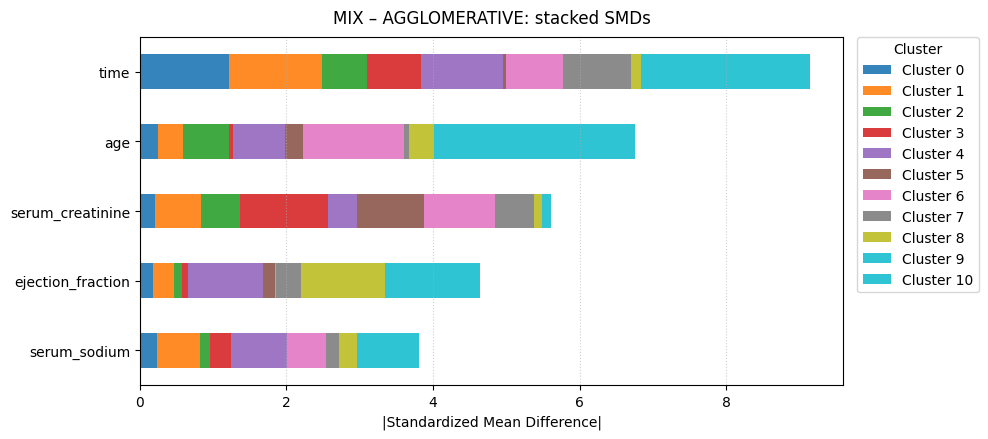

In [14]:
def plot_smd_stacked_bars(
    smd_df: pd.DataFrame,
    top_n: int = 8,
    use_abs: bool = True,
    title: str | None = None,
    legend_outside: bool = True,
):
    """
    Stacked horizontal bar chart:
      - Each row = feature (union of top-N per cluster)
      - Stacks = |SMD| values per cluster
      - Shows relative cluster contributions to feature importance
    """
    # --- Step 1: Select union of top features ---
    top_feats = set()
    for c in smd_df.columns:
        top_feats |= set(smd_df[c].abs().nlargest(top_n).index)
    top_feats = list(top_feats)

    df_plot = smd_df.loc[top_feats].copy()
    if use_abs:
        df_plot = df_plot.abs()
    df_plot = df_plot.fillna(0)

    # --- Step 2: Order features by total discriminative strength ---
    df_plot["Total"] = df_plot.sum(axis=1)
    df_plot = df_plot.sort_values("Total", ascending=True).drop(columns="Total")

    # --- Step 3: Create stacked horizontal bar plot ---
    fig, ax = plt.subplots(figsize=(10, 0.5 * len(df_plot) + 2))
    df_plot.plot.barh(
        stacked=True,
        ax=ax,
        colormap="tab10",   # 10 distinct colors
        alpha=0.9,
        edgecolor="none"
    )

    ax.set_xlabel("|Standardized Mean Difference|" if use_abs else "Standardized Mean Difference")
    ax.set_ylabel("")
    ax.set_title(title or "Stacked |SMD| per Feature", pad=10)
    ax.grid(axis="x", linestyle=":", alpha=0.6)

    # --- Step 4: Optional legend positioning ---
    if legend_outside: ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    else: ax.legend(title="Cluster")

    plt.tight_layout()
    plt.show()

rank1_key = (1, ordered[0]['emb'].upper(), ordered[0]['algo'].upper())
smd_df = top_smd_tables[rank1_key]

plot_smd_stacked_bars(
    smd_df,
    top_n=8,
    use_abs=True,
    title=f"{rank1_key[1]} – {rank1_key[2]}: stacked SMDs",
    legend_outside=True
)

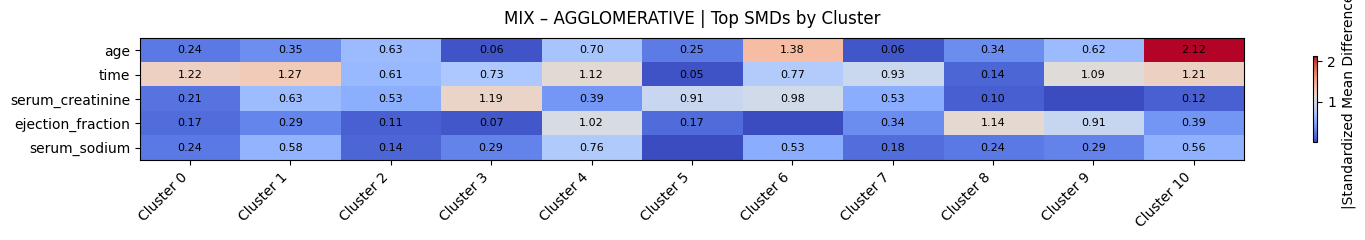

In [15]:
def plot_smd_heatmap(smd_df, top_n=8, title=None, abs_values=True):
    """
    Heatmap-like plot showing SMDs for all clusters (rows = features, cols = clusters).
    Much more readable than grouped/stacked bars.
    """
    # 1️⃣ pick union of top features across clusters
    top_feats = set()
    for c in smd_df.columns:
        top_feats |= set(smd_df[c].abs().nlargest(top_n).index)
    top_feats = sorted(top_feats)

    # 2️⃣ reorder by overall |SMD|
    df_plot = smd_df.loc[top_feats].copy()
    if abs_values:
        df_plot = df_plot.abs()
    df_plot = df_plot.loc[df_plot.max(axis=1).sort_values(ascending=False).index]

    # 3️⃣ plot as heatmap with annotations
    fig, ax = plt.subplots(figsize=(1.4 * len(df_plot.columns), 0.5 * len(df_plot)))
    im = ax.imshow(df_plot, cmap="coolwarm", aspect="auto")

    # axes
    ax.set_xticks(np.arange(len(df_plot.columns)))
    ax.set_yticks(np.arange(len(df_plot.index)))
    ax.set_xticklabels(df_plot.columns, rotation=45, ha="right")
    ax.set_yticklabels(df_plot.index)

    # colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.7, label="|Standardized Mean Difference|" if abs_values else "SMD")

    # annotation values
    for i in range(len(df_plot.index)):
        for j in range(len(df_plot.columns)):
            val = df_plot.iloc[i, j]
            if not np.isnan(val) and abs(val) > 0.05:
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black", fontsize=8)

    ax.set_title(title or "Top SMDs per Cluster", fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()


# Example: use on your best model
rank1_key = (1, ordered[0]['emb'].upper(), ordered[0]['algo'].upper())
plot_smd_heatmap(
    top_smd_tables[rank1_key],
    top_n=8,
    title=f"{rank1_key[1]} – {rank1_key[2]} | Top SMDs by Cluster"
)


In [16]:
for name, X in datasets.items():
    km = KMeans(n_clusters=2, random_state=SEED, n_init=50)
    labels = km.fit_predict(X)
    plot_clusters_target_3d(X, labels, y, title=f"{name} - KMeans vs DEATH_EVENT")


## Preprocessed dataset

In [17]:
db = DBSCAN(eps=0.3, min_samples=3)
km = KMeans(n_clusters=2, random_state=SEED)
ag = AgglomerativeClustering()

labels_db = db.fit_predict(X_pre)
labels_km = km.fit_predict(X_pre)
labels_ag = ag.fit_predict(X_pre)

In [18]:
show_scores("DBSCAN(pre)", X_pre, labels_db, y)
show_scores("KMeans(pre)", X_pre, labels_km, y)
show_scores("Agglo(pre)",  X_pre, labels_ag, y)

[DBSCAN(pre)] -> clusters=3, noise=2.9%, sil=0.08269899096802112, CH=5.45589071327888, DB=1.9596500146983802, ARI=0.016102190867454486, NMI=0.023963319671802562, V=0.023963319671802562
[KMeans(pre)] -> clusters=2, noise=0.0%, sil=0.23952552026338092, CH=108.90878265201502, DB=1.6036931062437398, ARI=0.4368534431867685, NMI=0.3961737566139229, V=0.3961737566139229
[Agglo(pre)] -> clusters=2, noise=0.0%, sil=0.20583695030875837, CH=86.52418642701447, DB=1.5348385954885237, ARI=0.05099244556220856, NMI=0.19001799498968197, V=0.19001799498968197


{'internal': {'silhouette': 0.20583695030875837,
  'calinski_harabasz': 86.52418642701447,
  'davies_bouldin': 1.5348385954885237,
  'n_clusters': 2,
  'noise_%': 0.0},
 'external': {'ARI': 0.05099244556220856,
  'NMI': 0.19001799498968197,
  'homogeneity': 0.18649554956964748,
  'completeness': 0.19367606276574292,
  'v_measure': 0.19001799498968197}}

In [19]:
reduce_3d_and_plot(X_pre, labels_db, "DBSCAN(pre)")
reduce_3d_and_plot(X_pre, labels_km, "KMeans(pre)")
reduce_3d_and_plot(X_pre, labels_ag, "Agglomerative Clustering(pre)")

[DBSCAN(pre)] PCA explained variance ratio: [0.37015963 0.22591455 0.18584541]


[KMeans(pre)] PCA explained variance ratio: [0.37015963 0.22591455 0.18584541]


[Agglomerative Clustering(pre)] PCA explained variance ratio: [0.37015963 0.22591455 0.18584541]


In [20]:
best = None
for eps in [0.3, 0.5, 0.8, 1.2]:
    for ms in [3,5,10]:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_pre)
        m = internal_scores(X_pre, labels)
        sil = m["silhouette"]

if best is not None: _, eps_b, ms_b = best

print(f"Best DBSCAN parameters: \neps = {eps_b} \nmin_samples = {ms_b}")

NameError: name 'eps_b' is not defined


KMeans on preprocessed


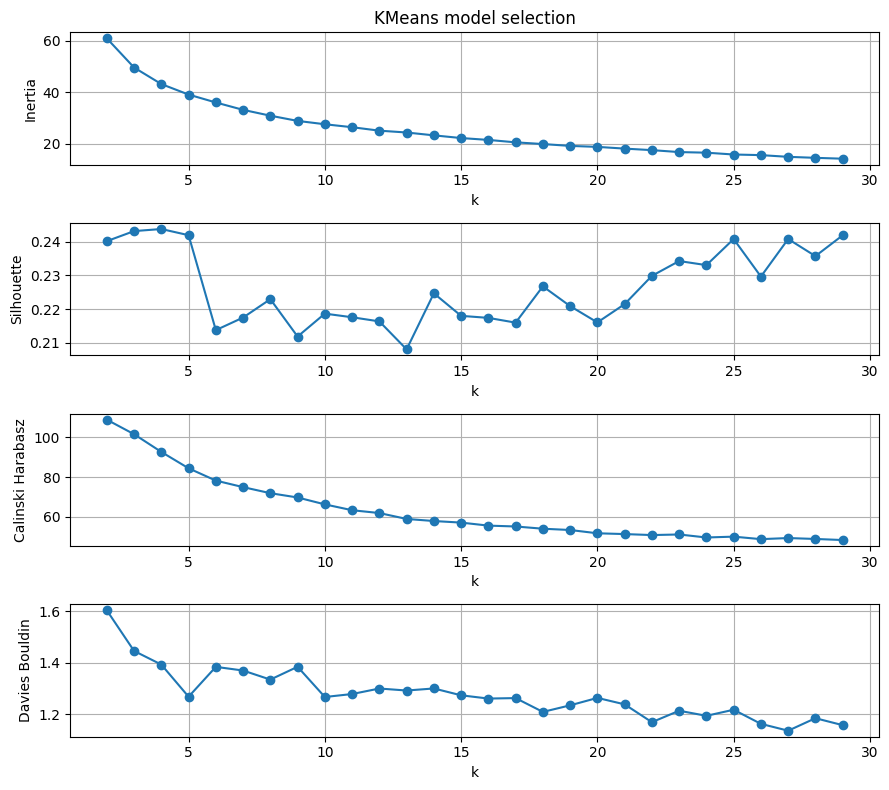


Agglomerative on preprocessed


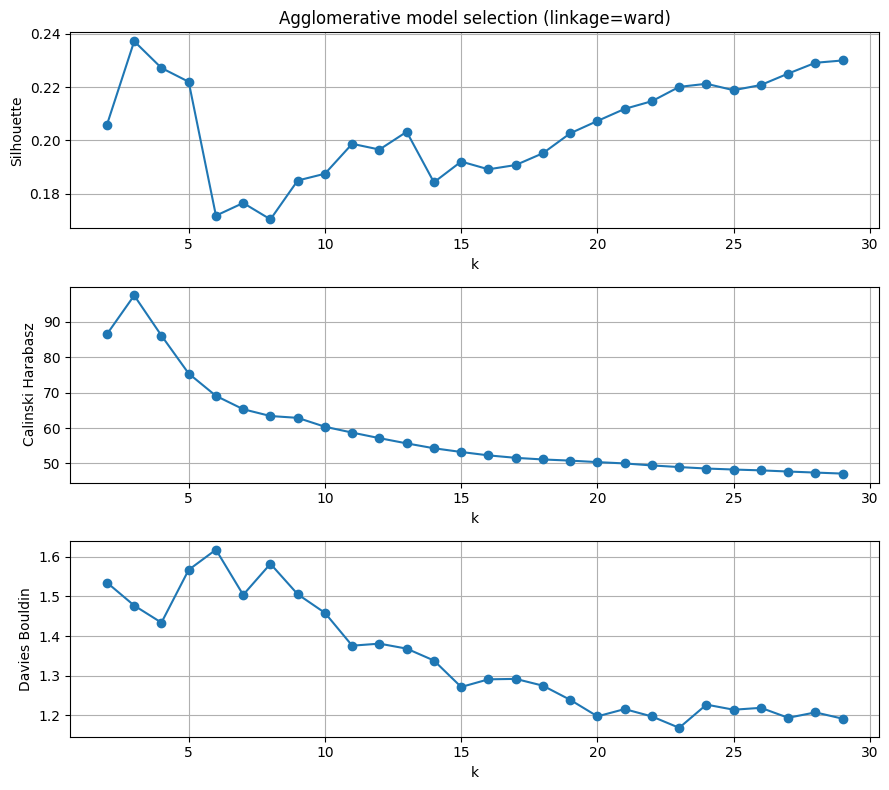

In [ ]:
print(f"\nKMeans on preprocessed")
kmeans_results['preprocessed'] = select_k_kmeans(X_pre,  k_range=range(2, 30), n_init=50)

print(f"\nAgglomerative on preprocessed")
agg_results['preprocessed']  = select_k_agglomerative(X_pre,  k_range=range(2, 30))

In [ ]:
print("\n— KMeans(pre) profile —")
display(cluster_profile(X_pre, labels_km))


— KMeans(pre) profile —


(               age                     ejection_fraction                      \
               mean    median       std              mean    median       std   
 _cluster                                                                       
 0         0.313090  0.290909  0.188069          0.505321  0.448598  0.205213   
 1         0.449955  0.438001  0.219486          0.355877  0.348879  0.209679   
 
          serum_creatinine                     serum_sodium            \
                      mean    median       std         mean    median   
 _cluster                                                               
 0                0.394353  0.387744  0.174494     0.545483  0.521739   
 1                0.661753  0.600866  0.247630     0.448695  0.478261   
 
                         time                      
                std      mean    median       std  
 _cluster                                          
 0         0.150701  0.614937  0.654804  0.217271  
 1         0.20303

In [ ]:
print("\n— Crosstab KMeans(pre) vs DEATH_EVENT —")
display(cluster_vs_target(labels_km, y))



— Crosstab KMeans(pre) vs DEATH_EVENT —


DEATH_EVENT,0,1,Count,Death_%
Cluster,,,,
0,157,6,163,3.7
1,46,99,145,68.3
